# Usage of PySpark SQL

In [1]:
from pyspark.sql import SparkSession

spark = (SparkSession.builder
                     .appName("Analyzing an unknown article.")
                     .getOrCreate())


In [22]:
## documentation
# spark.read?? # ?? after a function gives its documentation

In [9]:
file_path = r'article.txt' # fill in

In [10]:
article = spark.read.text(file_path) # article is a dataframe[value: string]

In [11]:
article.show(5, truncate=False) # use show() instead of just asking to display article

+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|value                                                                                                                                                                                                                                                                                                            |
+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|In a sign of the simmering discontent within the Make America Healthy Again

In [12]:
from pyspark.sql.functions import col # column

In [13]:

article.select(article.value)
article.select(article['value'])
article.select(col('value'))
article.select('value')

DataFrame[value: string]

In [14]:
from pyspark.sql.functions import col, split
lines = article.select(split(col('value'), ' ').alias('line'))
lines.show(5, truncate=False)

+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|line                                                                                                                                                                                                                                                                                                                                                               |
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [15]:
from pyspark.sql.functions import explode
words = lines.select(explode(col('line')).alias('word'))
words.show(5)

+----+
|word|
+----+
|  In|
|   a|
|sign|
|  of|
| the|
+----+
only showing top 5 rows


In [16]:
from pyspark.sql.functions import lower # standardization
words_lower = words.select(lower(col('word')).alias('word_lower'))
words_lower.show(5)

+----------+
|word_lower|
+----------+
|        in|
|         a|
|      sign|
|        of|
|       the|
+----------+
only showing top 5 rows


In [17]:
from pyspark.sql.functions import regexp_extract # other tasks such as getting rid of punctuation
word_clean = words_lower.select(regexp_extract(col('word_lower'), r'(\W+)?([a-z]+)', 2).alias('word'))
word_clean.show(5)

+----+
|word|
+----+
|  in|
|   a|
|sign|
|  of|
| the|
+----+
only showing top 5 rows


In [18]:
words_nonull = word_clean.where(col('word') != '') # filter out empty lines
words_nonull.show(5)

+----+
|word|
+----+
|  in|
|   a|
|sign|
|  of|
| the|
+----+
only showing top 5 rows


In [20]:
groups = words_nonull.groupby(col('word'))
groups

GroupedData[grouping expressions: [word], value: [word: string], type: GroupBy]

In [21]:
counts = groups.count()
counts.orderBy('count', ascending=False).show() # now have groups of words and how many times each appears

+--------------+-----+
|          word|count|
+--------------+-----+
|           the|  127|
|           and|   53|
|            to|   53|
|            of|   47|
|            in|   40|
|             a|   35|
|          that|   33|
|          with|   24|
|           epa|   21|
|            it|   21|
|            on|   19|
|administration|   18|
|            is|   18|
|           for|   17|
|           has|   17|
|          maha|   16|
|        health|   14|
|          this|   14|
|          they|   13|
|            at|   13|
+--------------+-----+
only showing top 20 rows


Exercise 1

In [42]:
# remove words with 3 or less letters
import pyspark.sql.functions as F

counts = (
    spark.read.text(file_path)
     .select(F.split(F.col('value'), ' ').alias('line'))
     .select(F.explode(F.col('line')).alias('word'))
     .select(F.lower(F.col('word')).alias('word'))
     .select(F.regexp_extract(F.col('word'), r"(\W+)?([a-z]+)", 2).alias('word'))
     .where(F.col('word') != "")
     .where(F.length(F.col('word')) > 3)
     .groupby('word')
     .count()
)

In [43]:
counts.orderBy('count', ascending=False).show()

+--------------+-----+
|          word|count|
+--------------+-----+
|          that|   33|
|          with|   24|
|administration|   18|
|          maha|   16|
|        health|   14|
|          this|   14|
|          they|   13|
|          says|   13|
|         trump|   12|
|         stone|   12|
|     chemicals|   12|
| environmental|   12|
|          what|   12|
|        agency|   11|
|    glyphosate|   11|
|       kennedy|   10|
|          like|   10|
|    pesticides|   10|
|       ryerson|    9|
|        zeldin|    8|
+--------------+-----+
only showing top 20 rows


Exercise 2

In [44]:
# build a table of word lengths and their occurrences frequencies
word_lengths = counts.select('word')
word_lengths = word_lengths.withColumn('length', F.length(F.col('word')))
word_lengths = word_lengths.groupby('length').count().orderBy('length')
word_lengths.show()

+------+-----+
|length|count|
+------+-----+
|     4|  101|
|     5|   91|
|     6|   91|
|     7|   75|
|     8|   61|
|     9|   71|
|    10|   30|
|    11|   15|
|    12|   14|
|    13|    5|
|    14|    1|
|    15|    1|
+------+-----+



Exercise 3

In [46]:
word_alphabet = counts
word_alphabet = word_alphabet.withColumn('alphabet', F.substring(F.col('word'), 1, 1))
word_alphabet = word_alphabet.groupby('alphabet').count().orderBy('alphabet')
word_alphabet.show()

+--------+-----+
|alphabet|count|
+--------+-----+
|       a|   48|
|       b|   20|
|       c|   49|
|       d|   29|
|       e|   31|
|       f|   26|
|       g|   20|
|       h|   24|
|       i|   24|
|       j|    3|
|       k|    8|
|       l|   21|
|       m|   26|
|       n|   11|
|       o|   15|
|       p|   38|
|       q|    1|
|       r|   31|
|       s|   59|
|       t|   25|
+--------+-----+
only showing top 20 rows


<Axes: xlabel='alphabet', ylabel='count'>

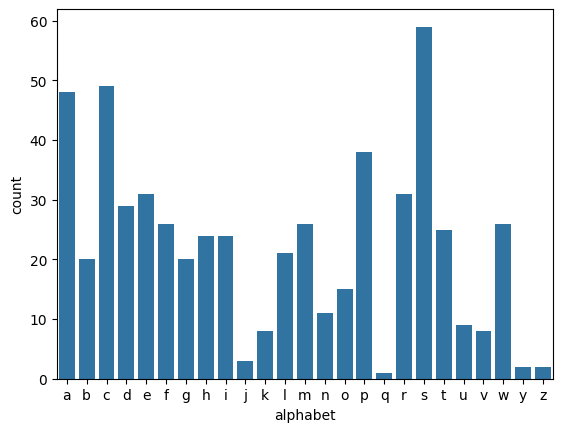

In [47]:
# create histogram of alphabet
import seaborn as sns
sns.barplot(data=word_alphabet.toPandas(), x='alphabet', y='count')